In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import model_2 as model

# Experiment 1: Agent Parameters

In [2]:
default_rewards = {i: 1 for i in range(100)}
default_rewards[0] = -10

In [3]:
ex = model.Memory(100, 5, default_rewards, mean_s=0)
print(ex.graph.nodes())

[[1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1]]


In [33]:
environment = model.Memory(100, 20, default_rewards, trauma_active=100)
agent = model.Agent()
test = model.Simulator(agent, environment)
test.run(20, 99, decay=False, print_message=True)
for trial in test.record:
    print(len(trial))
print(agent.vtable)

Trauma encountered in 20/20 retrievals (100.0%)
20
49
7
16
51
25
9
3
15
14
7
12
8
15
41
53
8
4
9
27
{84: -0.8845240510000001, 0: 1.906950867570199, 35: 1.1791, 38: 1.1791, 39: 1.171, 37: 1.1791, 45: 1.3473532000000001, 47: 0.36954662819485695, 46: 1.34741881, 48: 1.34085781, 70: 1.7410391918549966, 71: 1.7665044427622472, 72: 1.7518073678905592, 74: 1.5300287466714102, 73: 1.6636661960704722, 69: 1.4540416457104384, 67: 1.4924360280125553, 68: 1.4285711629, 65: 1.3812177450012555, 66: 1.373708737, 63: 0.479260666704601, 33: 1.09, 34: 1.25929, 30: 1.267309, 32: 1.267309, 31: 0.39312528774774225, 18: 1.363794349544432, 15: 0.719801589864133, 17: 1.489564939771902, 16: 1.4598878884725168, 19: 1.4388300348373493, 94: 1.5986570191165899, 90: 1.573937928946189, 92: 0.8742857755951001, 91: 1.5133537025200001, 3: 1.2959304694021, 2: 1.17689518, 4: 1.267309, 1: -0.5871645476246286, 61: 1.2670764490000002, 60: 1.2742404049, 62: 1.1791, 64: 1.3466759590000001, 10: 0.6204788557100281, 12: 1.566939

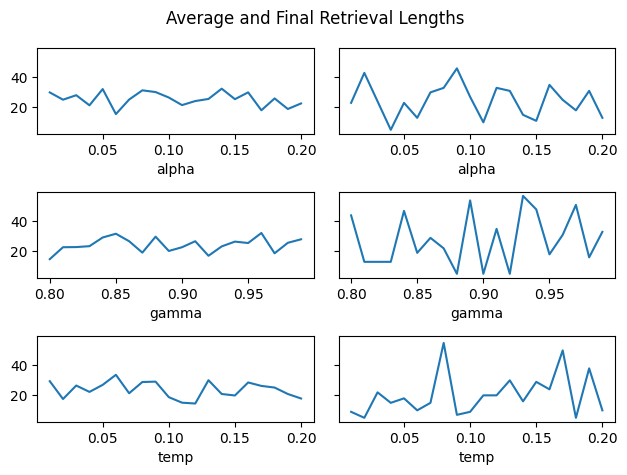

In [19]:
def exp_1(opt, params, n):
    avg_retrieval = []
    final_retrieval = []
    for p in params:
        if opt == "alpha":
            agent = model.Agent(alpha=p)
        elif opt == "gamma":
            agent = model.Agent(gamma=p)
        elif opt == "temp":
            agent = model.Agent(temp=p)
        environment = model.Memory(100, 20, default_rewards, trauma_active=0)
        test = model.Simulator(agent, environment)
        test.run(n, 99, time=0.1)
        retrieval_length = [len(trial) for trial in test.record]
        avg_retrieval.append(np.mean(retrieval_length))
        final_retrieval.append(retrieval_length[-1])
    return avg_retrieval, final_retrieval
    
fig, axs = plt.subplots(3, 2, sharey=True)
alphas = [n / 100 for n in range (1, 21)]
gammas = [n / 100 for n in range(80, 100)]
temps = [n / 100 for n in range(1, 21)]
ax_count = 0
for opt, params in {"alpha": alphas, "gamma": gammas, "temp": temps}.items():
    avg_retrieval, final_retrieval = exp_1(opt, params, 20)
    sns.lineplot(x=params, y=avg_retrieval, ax=axs[ax_count][0])
    sns.lineplot(x=params, y=final_retrieval, ax=axs[ax_count][1])
    axs[ax_count][0].set_xlabel(opt)
    axs[ax_count][1].set_xlabel(opt)
    ax_count += 1
fig.suptitle("Average and Final Retrieval Lengths")
plt.tight_layout()
plt.show()

# Experiment 2: Environment Parameters

In [5]:
def exp_2(n, groups, max_length, runs=100, time=0.1, rewards=None):
    agent = model.Agent()
    if rewards is None:
        rewards = {i: 1 for i in range(n)}
        rewards[0] = -10
    environment = model.Memory(n, groups, rewards)
    test = model.Simulator(agent, environment)
    test.run(runs, max_length, time=time)
    retrieval_length = [len(trial) for trial in test.record]
    return retrieval_length

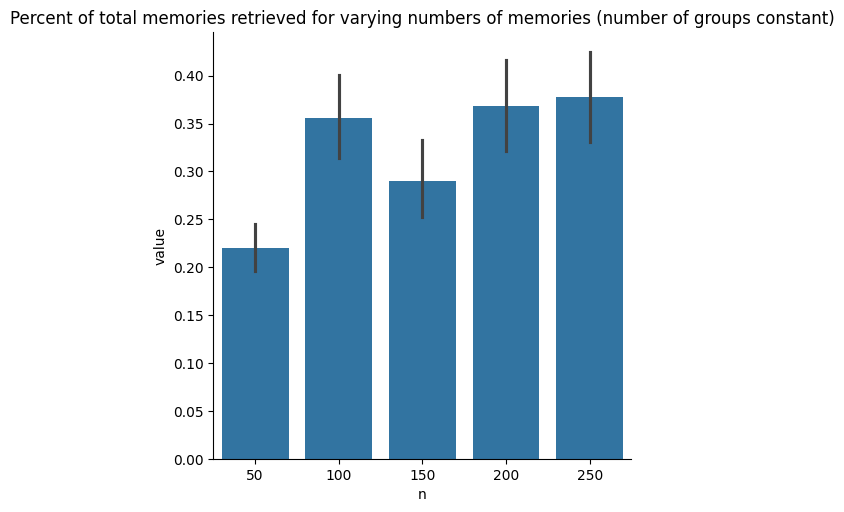

In [6]:
data = []
groups = 10
for i, n in enumerate([50, 100, 150, 200, 250]):
    rewards = {i: 1 for i in range(n)}
    for _ in range(i):
        rewards[_] = -10
    lengths = exp_2(n, groups, max_length=n - 1, rewards=rewards)
    for length in lengths:
        data.append({"n": n, "value": length / n})
sns.catplot(data=pd.DataFrame(data), x="n", y="value", kind="bar")
plt.title(f"Percent of total memories retrieved for varying numbers of memories (number of groups constant)")
plt.show()

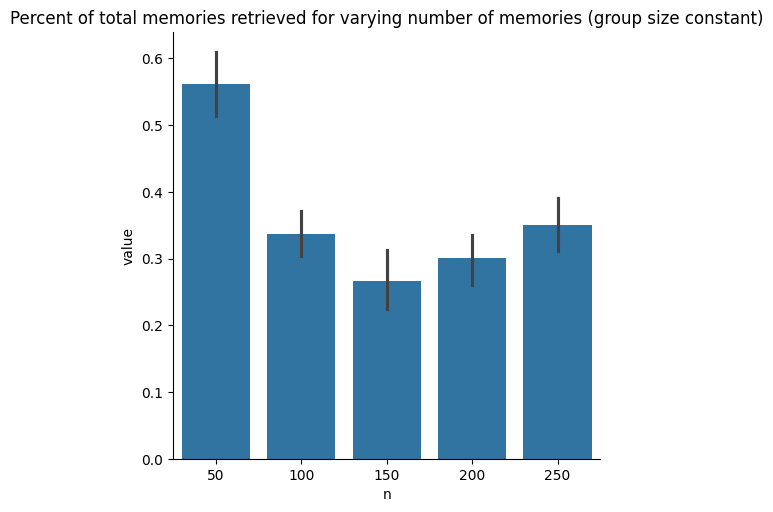

In [7]:
data = []
for i, n in enumerate([50, 100, 150, 200, 250]):
    rewards = {i: 1 for i in range(n)}
    groups = n // 10
    for _ in range(i):
        rewards[_] = -10
    lengths = exp_2(n, groups, max_length=n - 1, rewards=rewards)
    for length in lengths:
        data.append({"n": n, "value": length / n})
sns.catplot(data=pd.DataFrame(data), x="n", y="value", kind="bar")
plt.title(f"Percent of total memories retrieved for varying number of memories (group size constant)")
plt.show()

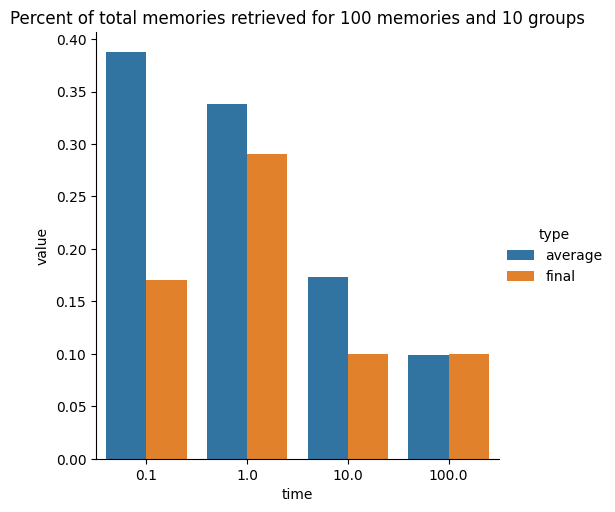

In [8]:
data = []
n = 100
groups = 10
for t in [0.1, 1, 10, 100]:
    lengths = exp_2(n, groups, max_length=n - 1, time=t)
    avg = np.mean(lengths)
    final = lengths[-1]
    data.append({"time": t, "type": "average", "value": avg / n})
    data.append({"time": t, "type": "final", "value": final / n})
sns.catplot(data=pd.DataFrame(data), x="time", y="value", hue="type", kind="bar")
plt.title(f"Percent of total memories retrieved for {n} memories and {groups} groups")
plt.show()

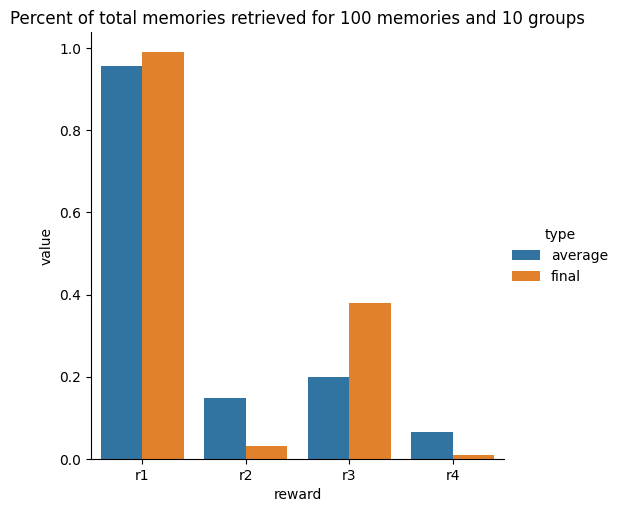

In [ ]:
data = []
groups = 10
n = 100
rewards = {i: 1 for i in range(n)}
rewards1 = rewards.copy()
rewards2 = rewards.copy()
rewards3 = rewards.copy()
rewards4 = rewards.copy()
rewards1[0] = -10
rewards2[0] = -100
for i in range(5):
    rewards3[i] = -10
    rewards4[i] = -100
for r, name in zip([rewards1, rewards2, rewards3, rewards4], ["r1", "r2", "r3", "r4"]):
    lengths = exp_2(n, groups, max_length=n - 1, time=0.1, rewards=r)
    avg = np.mean(lengths)
    final = lengths[-1]
    data.append({"reward": name, "type": "average", "value": avg / n})
    data.append({"reward": name, "type": "final", "value": final / n})
sns.catplot(data=pd.DataFrame(data), x="reward", y="value", hue="type", kind="bar")
plt.title(f"Percent of total memories retrieved for {n} memories and {groups} groups")
plt.show()